# ML Project — Preprocessing Effects on Classical Models (PhiUSIIL Phishing URL Dataset)

**Research question:**  
How do different feature preprocessing techniques (**none, normalization, standardization, PCA, whitening**) affect the **performance** and **stability** of classical ML models (**Logistic Regression, kNN, SVM, Naive Bayes**) on tabular datasets?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import make_scorer, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

print("ready")

ready


## 0) Load dataset

In [2]:
DATA_PATH = "PhiUSIIL_Phishing_URL_Dataset.csv"  
TARGET_COL = "label"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


int64      41
float64    10
object      5
Name: count, dtype: int64

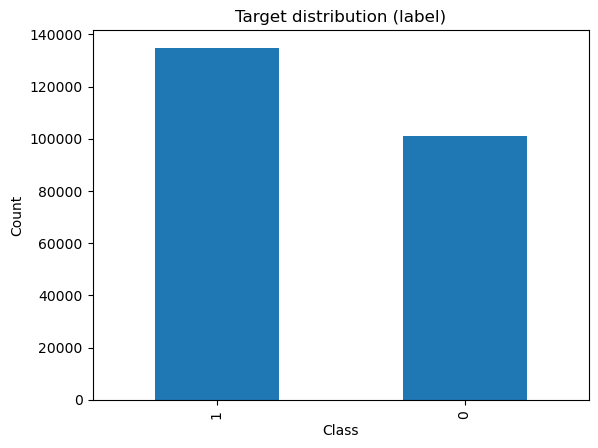

Counts: {1: 134850, 0: 100945}
Positive rate (label=1): 0.572
No missing values detected.


In [3]:
# Basic types
display(df.dtypes.value_counts())

# Target distribution
counts = df[TARGET_COL].value_counts()
counts.plot(kind="bar")
plt.title("Target distribution (label)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Counts:", counts.to_dict())
print("Positive rate (label=1):", round(counts.get(1,0)/counts.sum(), 3))

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
nz = missing[missing > 0]
if len(nz) == 0:
    print("No missing values detected.")
else:
    display(nz.head(30))
    nz.head(30).plot(kind="bar")
    plt.title("Missing values (top 30)")
    plt.xlabel("Column")
    plt.ylabel("Missing count")
    plt.show()

### Numeric vs non-numeric columns

For this project, we will:
- **Use all numeric columns as features**
- **Drop string columns** 


Numeric feature columns: 50
Non-numeric columns dropped: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
X_num shape: (235795, 50)


,min,25%,50%,75%,max
URLLength,13.000000,23.000000,27.000000,34.000000,6097.000000
DomainLength,4.000000,16.000000,20.000000,24.000000,110.000000
IsDomainIP,0.000000,0.000000,0.000000,0.000000,1.000000
URLSimilarityIndex,0.155574,57.024793,100.000000,100.000000,100.000000
CharContinuationRate,0.000000,0.680000,1.000000,1.000000,1.000000
TLDLegitimateProb,0.000000,0.005977,0.079963,0.522907,0.522907
URLCharProb,0.001083,0.050747,0.057970,0.062875,0.090824
TLDLength,2.000000,2.000000,3.000000,3.000000,13.000000
NoOfSubDomain,0.000000,1.000000,1.000000,1.000000,10.000000
HasObfuscation,0.000000,0.000000,0.000000,0.000000,1.000000


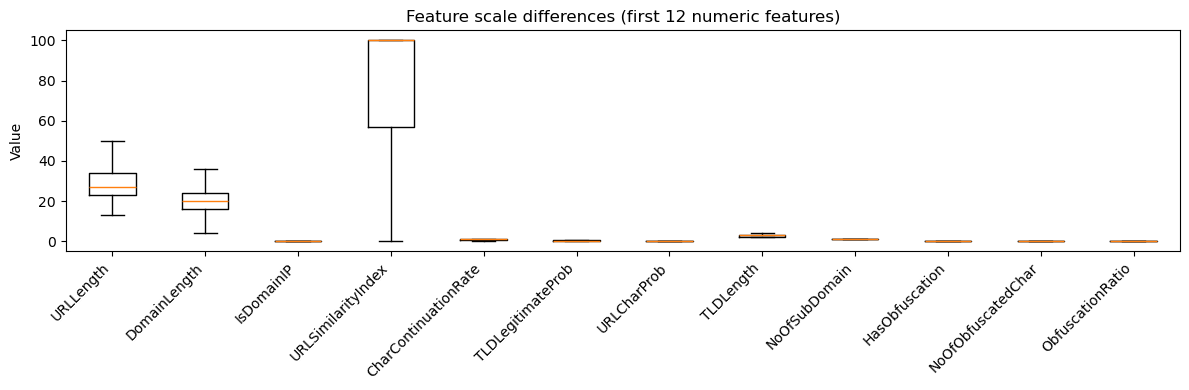

In [4]:
# Split into X/y
y = df[TARGET_COL].astype(int).values

# Keep numeric features only
X = df.drop(columns=[TARGET_COL])
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = [c for c in X.columns if c not in num_cols]

print("Numeric feature columns:", len(num_cols))
print("Non-numeric columns dropped:", obj_cols)

X_num = X[num_cols].copy()
print("X_num shape:", X_num.shape)

sample_cols = num_cols[:12]
desc = X_num[sample_cols].describe().T[["min","25%","50%","75%","max"]]
display(desc)

plt.figure(figsize=(12,4))
plt.boxplot([X_num[c].values for c in sample_cols], tick_labels=sample_cols, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title("Feature scale differences (first 12 numeric features)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

groups_all = df["Domain"].astype(str).values if "Domain" in df.columns else None


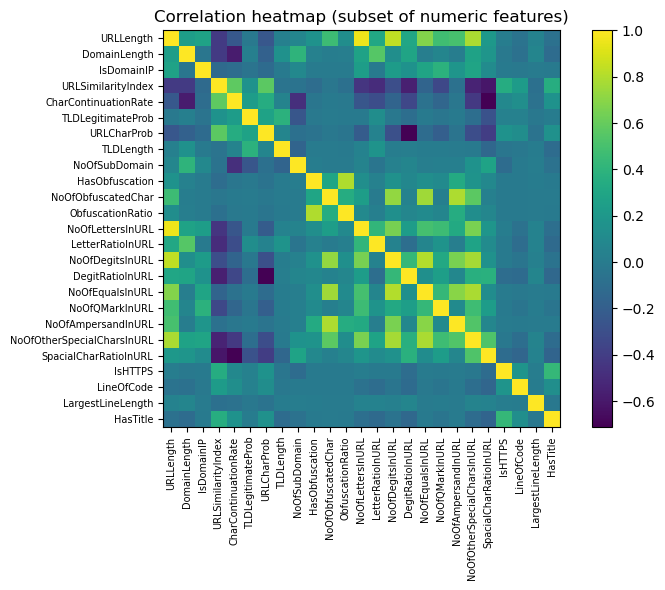

In [5]:
subset = num_cols[:25]
corr = X_num[subset].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr.values)
plt.title("Correlation heatmap (subset of numeric features)")
plt.xticks(range(len(subset)), subset, rotation=90, fontsize=7)
plt.yticks(range(len(subset)), subset, fontsize=7)
plt.colorbar()
plt.tight_layout()
plt.show()

###  week 5 takeaways 




In [6]:
takeaways = []
takeaways.append(f"- Dataset size: {df.shape[0]:,} rows with {len(num_cols)} numeric features → good for stable cross-validation comparisons.")
takeaways.append("- Clear class label and no missing values → preprocessing effects are not confounded by imputation choices.")
takeaways.append("- Feature scales differ substantially (see boxplot) → normalization/standardization should matter for distance/margin-based models (kNN, SVM).")
takeaways.append("- Many features are correlated (heatmap) → PCA/whitening may reduce redundancy and stabilize models.")

print("Week 5 takeaways:")
for t in takeaways:
    print(t)

Week 5 takeaways:
- Dataset size: 235,795 rows with 50 numeric features → good for stable cross-validation comparisons.
- Clear class label and no missing values → preprocessing effects are not confounded by imputation choices.
- Feature scales differ substantially (see boxplot) → normalization/standardization should matter for distance/margin-based models (kNN, SVM).
- Many features are correlated (heatmap) → PCA/whitening may reduce redundancy and stabilize models.


In [7]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# Safety: if you ran cells out of order, fall back to full data
if "X_exp" not in globals():
    X_exp = X_num.values
if "y_exp" not in globals():
    y_exp = y
if "N_SPLITS" not in globals():
    N_SPLITS = 3
if "groups_exp" not in globals():
    groups_exp = groups_all if ("groups_all" in globals() and groups_all is not None) else None

# 1) Duplicate check in numeric feature space
dup_count = X_num.duplicated().sum()
print(f"Duplicate rows in numeric feature matrix: {dup_count} / {len(X_num)} ({dup_count/len(X_num):.3%})")

# 2) Label-shuffle sanity check (AUC should be ~0.5)
rng = np.random.RandomState(42)
y_shuf = rng.permutation(y)

Xt, Xv, yt, yv = train_test_split(
    X_num.values, y_shuf, test_size=0.2, random_state=42, stratify=y_shuf
)

sanity_pipe = Pipeline([
    ("prep", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])
sanity_pipe.fit(Xt, yt)

score = sanity_pipe.predict_proba(Xv)[:, 1] if hasattr(sanity_pipe.named_steps["model"], "predict_proba") else sanity_pipe.decision_function(Xv)
print("Label-shuffle ROC-AUC (should be ~0.5):", round(roc_auc_score(yv, score), 3))

# 3) Domain-grouped CV (prevents same-domain leakage across folds)
if groups_exp is not None:
    gcv = GroupKFold(n_splits=N_SPLITS)

    pipe = Pipeline([
        ("prep", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, tol=1e-3, class_weight="balanced"))
    ])

    aucs = []
    for tr, te in gcv.split(X_exp, y_exp, groups=groups_exp):
        pipe.fit(X_exp[tr], y_exp[tr])
        s = pipe.predict_proba(X_exp[te])[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else pipe.decision_function(X_exp[te])
        aucs.append(roc_auc_score(y_exp[te], s))

    print("Domain-GroupKFold ROC-AUC (LogReg+standard): mean=", round(np.mean(aucs), 3), "std=", round(np.std(aucs), 3))
else:
    print("No Domain column available for grouping; skipping GroupKFold check.")

Duplicate rows in numeric feature matrix: 808 / 235795 (0.343%)
Label-shuffle ROC-AUC (should be ~0.5): 0.499
Domain-GroupKFold ROC-AUC (LogReg+standard): mean= 1.0 std= 0.0


## 2) Experiment setup

We compare preprocessing variants:
- **none** (no scaling)
- **minmax** (normalization to [0,1])
- **standard** (zero mean, unit variance)
- **pca** (standardize → PCA to keep 95% variance)
- **whiten** (standardize → PCA(whiten=True) to keep 95% variance)

And models:
- Logistic Regression
- kNN
- SVM (RBF)
- Gaussian Naive Bayes

We report both:
- **Performance** (ROC-AUC, balanced accuracy, F1 for positive class)
- **Stability** (std across folds)


In [8]:
from sklearn.metrics import balanced_accuracy_score

def make_preprocess(variant: str):
    if variant == "none":
        return "passthrough"
    if variant == "minmax":
        return MinMaxScaler()
    if variant == "standard":
        return StandardScaler()
    if variant == "pca":
        return Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
        ])
    if variant == "whiten":
        return Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.95, svd_solver="full", whiten=True)),
        ])
    raise ValueError("Unknown variant")

models = {
    "LogReg": LogisticRegression(max_iter=10000, tol=1e-3, class_weight="balanced"),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "SVM_Linear": LinearSVC(class_weight="balanced"),
    # Keep RBF SVM only for the optional visualization section (Part 3)
    "SVM_RBF": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "NaiveBayes": GaussianNB()
}

variants = ["none", "minmax", "standard", "pca", "whiten"]

scoring = {
    "roc_auc": "roc_auc",
    "bal_acc": "balanced_accuracy",
    "f1_pos": make_scorer(f1_score, pos_label=1),
}

In [9]:

SPEED_PROFILE = "fast"

if SPEED_PROFILE == "fast":
    SAMPLE_N = 10000
    N_SPLITS = 3
else:
    SAMPLE_N = None   # full dataset
    N_SPLITS = 5

rng = np.random.RandomState(42)

# Subsample if requested
if SAMPLE_N is not None and SAMPLE_N < len(X_num):
    idx = rng.choice(len(X_num), size=SAMPLE_N, replace=False)
    X_exp = X_num.iloc[idx].values
    y_exp = y[idx]
else:
    idx = None
    X_exp = X_num.values
    y_exp = y

# groups for Domain-based evaluation (only used for splitting)
if "groups_all" in globals() and groups_all is not None:
    groups_exp = groups_all[idx] if idx is not None else groups_all
else:
    groups_exp = None

print("Speed profile:", SPEED_PROFILE)
print("Experiment X shape:", X_exp.shape)
print("CV folds:", N_SPLITS)
print("Domain groups available:", groups_exp is not None)

Speed profile: fast
Experiment X shape: (10000, 50)
CV folds: 3
Domain groups available: True


### Cross-validated comparison table (mean ± std)

In [10]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

rows = []
for v in variants:
    prep = make_preprocess(v)
    for mname, model in models.items():
        pipe = Pipeline([
            ("prep", prep),
            ("model", model),
        ])
        scores = cross_validate(pipe, X_exp, y_exp, cv=cv, scoring=scoring, n_jobs=1)
        rows.append({
            "variant": v,
            "model": mname,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "bal_acc_mean": scores["test_bal_acc"].mean(),
            "bal_acc_std": scores["test_bal_acc"].std(),
            "f1_pos_mean": scores["test_f1_pos"].mean(),
            "f1_pos_std": scores["test_f1_pos"].std(),
        })

results_df = pd.DataFrame(rows).sort_values(["roc_auc_mean"], ascending=False)
display(results_df)

,variant,model,roc_auc_mean,roc_auc_std,bal_acc_mean,bal_acc_std,f1_pos_mean,f1_pos_std
12,standard,SVM_Linear,1.000000,0.000000e+00,0.999884,0.000164,0.999912,0.000124
7,minmax,SVM_Linear,1.000000,0.000000e+00,0.999884,0.000164,0.999912,0.000124
22,whiten,SVM_Linear,1.000000,3.462160e-07,0.999535,0.000435,0.999650,0.000328
8,minmax,SVM_RBF,0.999999,1.211333e-06,0.999767,0.000165,0.999825,0.000124
10,standard,LogReg,0.999999,1.557428e-06,0.999563,0.000617,0.999649,0.000496
13,standard,SVM_RBF,0.999997,2.549117e-06,0.998599,0.000399,0.998684,0.000431
20,whiten,LogReg,0.999995,4.607115e-06,0.998631,0.000638,0.998861,0.000495
5,minmax,LogReg,0.999995,6.602871e-06,0.999096,0.000465,0.999211,0.000430
15,pca,LogReg,0.999994,3.462039e-06,0.999096,0.000474,0.999211,0.000372
18,pca,SVM_RBF,0.999991,9.576704e-06,0.998454,0.000465,0.998596,0.000448


### Simple plot: ROC-AUC mean by preprocessing (grouped bar per model)




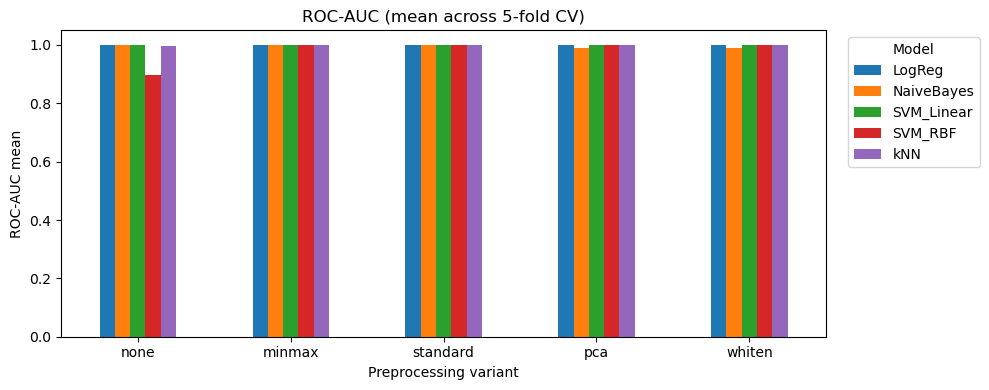

In [11]:
# Pivot for plotting
pivot = results_df.pivot(index="variant", columns="model", values="roc_auc_mean").loc[variants]

pivot.plot(kind="bar", figsize=(10,4))
plt.title("ROC-AUC (mean across 5-fold CV)")
plt.xlabel("Preprocessing variant")
plt.ylabel("ROC-AUC mean")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2c) Extra test: severe scale distortion experiment

This is a **stress test for scale robustness**.

Instead of multiplying only a few features by the same constant, we now distort **all numeric features** with **very different magnitudes**:
- some features are shrunk heavily (e.g. ×1e-6),
- some are enlarged heavily (e.g. ×1e6),
- and others stay in between.

This creates a much harsher scale imbalance than before.

Why this version is better:
- It makes the **no preprocessing** case much more fragile.
- It gives **scale-sensitive models** (especially **kNN**, **SVM**, and sometimes **LogReg**) a harder setting.
- It helps show whether preprocessing methods such as **standardization** or **min-max scaling** can recover performance.

Important note:
- On very easy datasets, **ROC-AUC may still remain high**.
- Therefore we compare **ROC-AUC**, **balanced accuracy**, and **F1** together, not ROC-AUC alone.


Applied severe per-feature scale distortion.
Smallest multiplier: 1e-06
Largest multiplier: 1000000.0


,feature,multiplier,log10_multiplier
40,Bank,0.0000,-6.0000
47,NoOfSelfRef,0.0000,-5.7551
44,NoOfImage,0.0000,-5.5102
30,NoOfURLRedirect,0.0000,-5.2653
16,NoOfEqualsInURL,0.0000,-5.0204
0,URLLength,0.0000,-4.7755
35,HasExternalFormSubmit,0.0000,-4.5306
15,DegitRatioInURL,0.0001,-4.2857
49,NoOfExternalRef,0.0001,-4.0408
21,IsHTTPS,0.0002,-3.7959


,feature,multiplier,log10_multiplier
12,NoOfLettersInURL,6250.5519,3.7959
25,DomainTitleMatchScore,10985.4114,4.0408
27,HasFavicon,19306.9773,4.2857
34,NoOfiFrame,33932.2177,4.5306
31,NoOfSelfRedirect,59636.2332,4.7755
7,TLDLength,104811.3134,5.0204
8,NoOfSubDomain,184206.9969,5.2653
6,URLCharProb,323745.7543,5.5102
43,HasCopyrightInfo,568986.6029,5.7551
3,URLSimilarityIndex,1000000.0000,6.0000


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,variant,model,roc_auc_mean_original,roc_auc_mean_distorted,roc_auc_drop,bal_acc_mean_original,bal_acc_mean_distorted,bal_acc_drop,f1_pos_mean_original,f1_pos_mean_distorted,f1_pos_drop
5,minmax,LogReg,0.999995,0.999995,0.000000,0.999096,0.999096,0.000000,0.999211,0.999211,0.000000
0,none,LogReg,0.999985,0.999850,0.000135,0.999155,0.995629,0.003526,0.999299,0.996320,0.002979
15,pca,LogReg,0.999994,0.999994,0.000000,0.999096,0.999096,0.000000,0.999211,0.999211,0.000000
10,standard,LogReg,0.999999,0.999999,0.000000,0.999563,0.999563,0.000000,0.999649,0.999649,0.000000
20,whiten,LogReg,0.999995,0.999995,0.000000,0.998631,0.998631,0.000000,0.998861,0.998861,0.000000
9,minmax,NaiveBayes,0.999884,0.999884,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
4,none,NaiveBayes,0.999703,0.999978,-0.000276,0.993251,0.996072,-0.002822,0.993295,0.997028,-0.003733
19,pca,NaiveBayes,0.990175,0.990175,0.000000,0.977616,0.977616,0.000000,0.980796,0.980796,0.000000
14,standard,NaiveBayes,0.999884,0.999884,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
24,whiten,NaiveBayes,0.990175,0.990175,0.000000,0.977616,0.977616,0.000000,0.980796,0.980796,0.000000


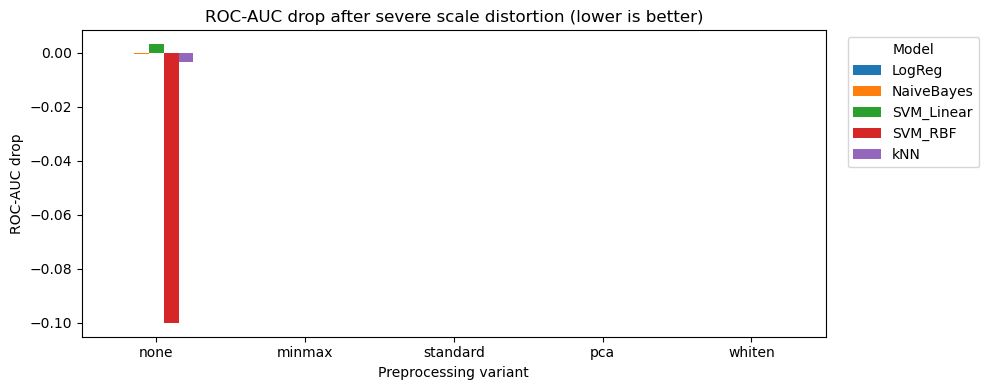

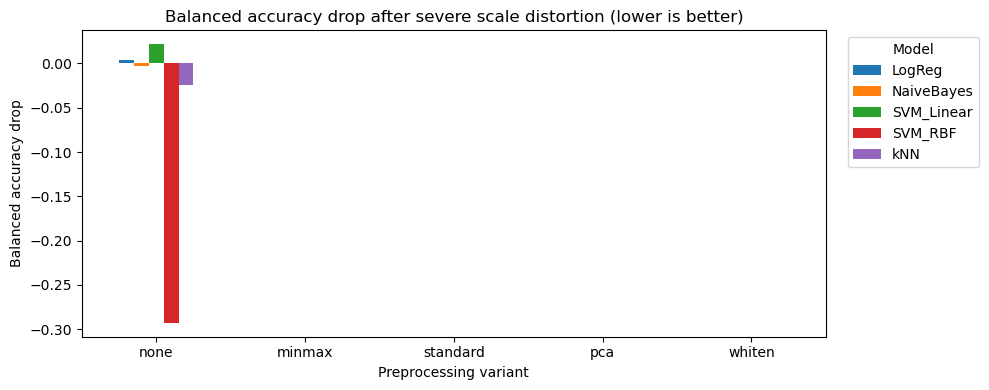

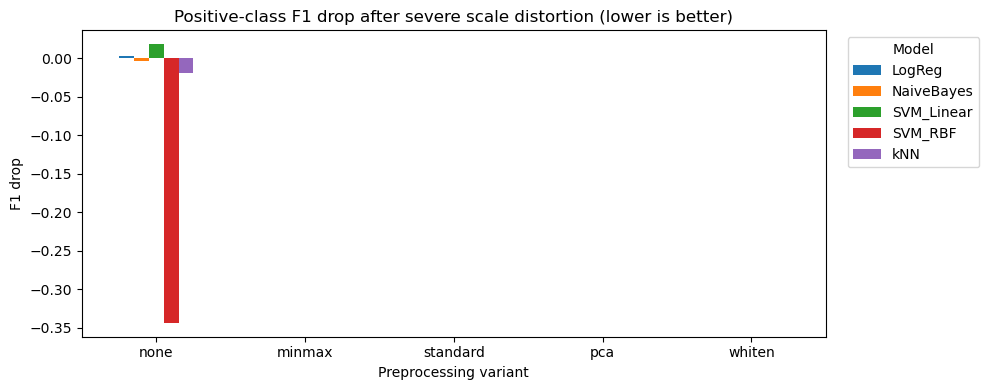

Focused comparison for the most scale-relevant variants:


,variant,model,roc_auc_mean_original,roc_auc_mean_distorted,roc_auc_drop,bal_acc_mean_original,bal_acc_mean_distorted,bal_acc_drop,f1_pos_mean_original,f1_pos_mean_distorted,f1_pos_drop
5,minmax,LogReg,0.999995,0.999995,0.000000,0.999096,0.999096,0.000000,0.999211,0.999211,0.000000
0,none,LogReg,0.999985,0.999850,0.000135,0.999155,0.995629,0.003526,0.999299,0.996320,0.002979
10,standard,LogReg,0.999999,0.999999,0.000000,0.999563,0.999563,0.000000,0.999649,0.999649,0.000000
9,minmax,NaiveBayes,0.999884,0.999884,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
4,none,NaiveBayes,0.999703,0.999978,-0.000276,0.993251,0.996072,-0.002822,0.993295,0.997028,-0.003733
14,standard,NaiveBayes,0.999884,0.999884,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
7,minmax,SVM_Linear,1.000000,1.000000,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
2,none,SVM_Linear,0.999943,0.996706,0.003237,0.995714,0.974126,0.021588,0.996228,0.978343,0.017885
12,standard,SVM_Linear,1.000000,1.000000,0.000000,0.999884,0.999884,0.000000,0.999912,0.999912,0.000000
8,minmax,SVM_RBF,0.999999,0.999999,0.000000,0.999767,0.999767,0.000000,0.999825,0.999825,0.000000


Interpretation guide:
- If `none` drops much more than `standard` or `minmax`, preprocessing improves robustness.
- If ROC-AUC stays high but balanced accuracy / F1 drop, the dataset remains separable but threshold-level predictions became less stable.
- This is expected on easy datasets where ROC-AUC can saturate near 1.0.


In [12]:
# Severe scale distortion: distort ALL numeric features with very different magnitudes
rng = np.random.default_rng(42)

n_features = X_exp.shape[1]
distorted_feature_idx = np.arange(n_features)
distorted_feature_names = [num_cols[i] for i in distorted_feature_idx]

# Deterministic log-scale multipliers spanning a huge range.
# Example values look like: 1e-6, 1e-5, ..., 1e5, 1e6 (shuffled)
log_powers = np.linspace(-6, 6, n_features)
rng.shuffle(log_powers)
feature_multipliers = np.power(10.0, log_powers)

X_distorted = X_exp.copy().astype(float)
X_distorted *= feature_multipliers

multiplier_df = pd.DataFrame({
    "feature": distorted_feature_names,
    "multiplier": feature_multipliers,
    "log10_multiplier": np.log10(feature_multipliers),
}).sort_values("log10_multiplier")

print("Applied severe per-feature scale distortion.")
print("Smallest multiplier:", feature_multipliers.min())
print("Largest multiplier:", feature_multipliers.max())
display(multiplier_df.head(10).round(4))
display(multiplier_df.tail(10).round(4))

# Evaluate original vs distorted side by side
dist_rows = []
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

for dataset_name, X_current in [("original", X_exp), ("distorted", X_distorted)]:
    for v in variants:
        prep = make_preprocess(v)
        for mname, model in models.items():
            pipe = Pipeline([
                ("prep", prep),
                ("model", model),
            ])
            scores = cross_validate(pipe, X_current, y_exp, cv=cv, scoring=scoring, n_jobs=1)
            dist_rows.append({
                "dataset": dataset_name,
                "variant": v,
                "model": mname,
                "roc_auc_mean": scores["test_roc_auc"].mean(),
                "roc_auc_std": scores["test_roc_auc"].std(),
                "bal_acc_mean": scores["test_bal_acc"].mean(),
                "bal_acc_std": scores["test_bal_acc"].std(),
                "f1_pos_mean": scores["test_f1_pos"].mean(),
                "f1_pos_std": scores["test_f1_pos"].std(),
            })

scale_stress_df = pd.DataFrame(dist_rows)

orig_df = (
    scale_stress_df[scale_stress_df["dataset"] == "original"]
    .drop(columns=["dataset"])
    .rename(columns={
        "roc_auc_mean": "roc_auc_mean_original",
        "roc_auc_std": "roc_auc_std_original",
        "bal_acc_mean": "bal_acc_mean_original",
        "bal_acc_std": "bal_acc_std_original",
        "f1_pos_mean": "f1_pos_mean_original",
        "f1_pos_std": "f1_pos_std_original",
    })
)

dist_df = (
    scale_stress_df[scale_stress_df["dataset"] == "distorted"]
    .drop(columns=["dataset"])
    .rename(columns={
        "roc_auc_mean": "roc_auc_mean_distorted",
        "roc_auc_std": "roc_auc_std_distorted",
        "bal_acc_mean": "bal_acc_mean_distorted",
        "bal_acc_std": "bal_acc_std_distorted",
        "f1_pos_mean": "f1_pos_mean_distorted",
        "f1_pos_std": "f1_pos_std_distorted",
    })
)

scale_compare = orig_df.merge(dist_df, on=["variant", "model"], how="inner")
scale_compare["roc_auc_drop"] = scale_compare["roc_auc_mean_original"] - scale_compare["roc_auc_mean_distorted"]
scale_compare["bal_acc_drop"] = scale_compare["bal_acc_mean_original"] - scale_compare["bal_acc_mean_distorted"]
scale_compare["f1_pos_drop"] = scale_compare["f1_pos_mean_original"] - scale_compare["f1_pos_mean_distorted"]

display_cols = [
    "variant", "model",
    "roc_auc_mean_original", "roc_auc_mean_distorted", "roc_auc_drop",
    "bal_acc_mean_original", "bal_acc_mean_distorted", "bal_acc_drop",
    "f1_pos_mean_original", "f1_pos_mean_distorted", "f1_pos_drop",
]
display(scale_compare[display_cols].sort_values(["model", "variant"]).round(6))

# Plot 1: ROC-AUC drop
pivot_auc = scale_compare.pivot(index="variant", columns="model", values="roc_auc_drop").loc[variants]
pivot_auc.plot(kind="bar", figsize=(10, 4))
plt.title("ROC-AUC drop after severe scale distortion (lower is better)")
plt.xlabel("Preprocessing variant")
plt.ylabel("ROC-AUC drop")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 2: Balanced accuracy drop
pivot_bal = scale_compare.pivot(index="variant", columns="model", values="bal_acc_drop").loc[variants]
pivot_bal.plot(kind="bar", figsize=(10, 4))
plt.title("Balanced accuracy drop after severe scale distortion (lower is better)")
plt.xlabel("Preprocessing variant")
plt.ylabel("Balanced accuracy drop")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 3: F1 drop
pivot_f1 = scale_compare.pivot(index="variant", columns="model", values="f1_pos_drop").loc[variants]
pivot_f1.plot(kind="bar", figsize=(10, 4))
plt.title("Positive-class F1 drop after severe scale distortion (lower is better)")
plt.xlabel("Preprocessing variant")
plt.ylabel("F1 drop")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Optional focused table: the variants most relevant for scale sensitivity
focus_variants = [v for v in ["none", "standard", "minmax"] if v in variants]
if focus_variants:
    focused = scale_compare[scale_compare["variant"].isin(focus_variants)].copy()
    print("Focused comparison for the most scale-relevant variants:")
    display(focused[display_cols].sort_values(["model", "variant"]).round(6))

print("Interpretation guide:")
print("- If `none` drops much more than `standard` or `minmax`, preprocessing improves robustness.")
print("- If ROC-AUC stays high but balanced accuracy / F1 drop, the dataset remains separable but threshold-level predictions became less stable.")
print("- This is expected on easy datasets where ROC-AUC can saturate near 1.0.")


## 2b)  ROC then AUC 



- Figure 1: ROC curves only 
- Figure 2: AUC values as a bar chart


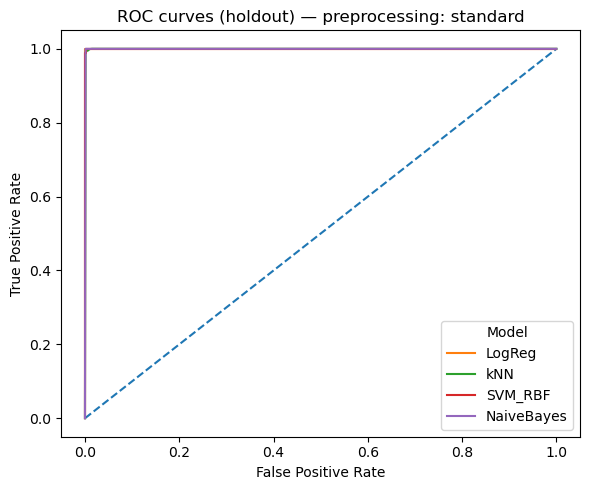

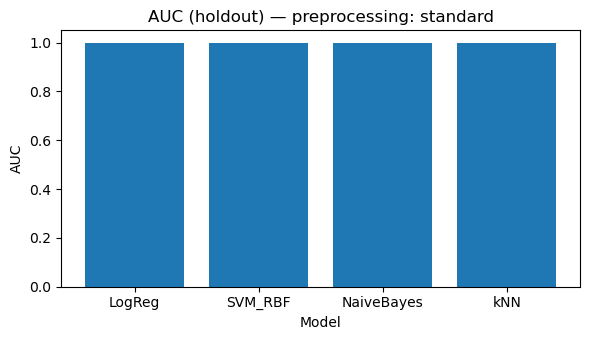

,model,auc
0,LogReg,0.999999
2,SVM_RBF,0.999988
3,NaiveBayes,0.999418
1,kNN,0.999365


In [13]:
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

roc_variant = "standard"

# Choose which models to include in the ROC plot
roc_models = ["LogReg", "kNN", "SVM_RBF", "NaiveBayes"]

roc_results = []

# --- Figure 1: ROC curves only ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title(f"ROC curves (holdout) — preprocessing: {roc_variant}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

for name in roc_models:
    pipe = Pipeline([
        ("prep", make_preprocess(roc_variant)),
        ("model", models[name]),
    ])
    pipe.fit(X_train, y_train)

    # Score for ROC: prefer predict_proba, else decision_function
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, label=name)

    auc_val = roc_auc_score(y_test, y_score)
    roc_results.append((name, auc_val))

ax.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

# --- Figure 2: AUC values only ---
roc_df = pd.DataFrame(roc_results, columns=["model", "auc"]).sort_values("auc", ascending=False)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(roc_df["model"], roc_df["auc"])
ax.set_ylim(0.0, 1.05)
ax.set_title(f"AUC (holdout) — preprocessing: {roc_variant}")
ax.set_xlabel("Model")
ax.set_ylabel("AUC")
plt.tight_layout()
plt.show()

display(roc_df)

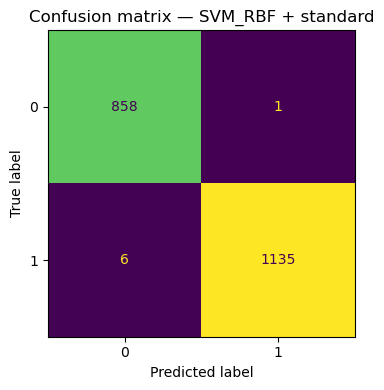

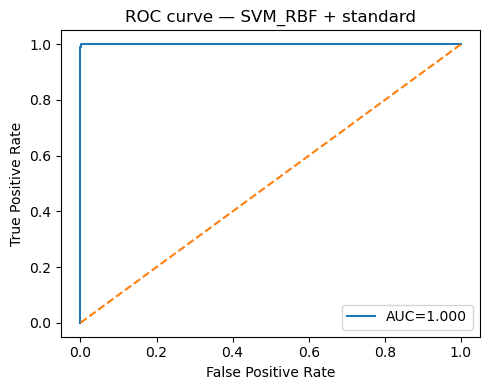

Holdout accuracy: 0.997 | Holdout ROC-AUC: 1.000


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# Pick one "reasonable" pipeline to visualize (change as you like)
viz_variant = "standard"
viz_model_name = "SVM_RBF"

pipe = Pipeline([
    ("prep", make_preprocess(viz_variant)),
    ("model", models[viz_model_name]),
])

pipe.fit(X_train, y_train)

# --- Confusion matrix (visual) ---
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix — {viz_model_name} + {viz_variant}")
plt.tight_layout()
plt.show()

# --- ROC curve (visual) ---
if hasattr(pipe.named_steps["model"], "predict_proba"):
    y_score = pipe.predict_proba(X_test)[:, 1]
else:
    y_score = pipe.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC curve — {viz_model_name} + {viz_variant}")
ax.legend()
plt.tight_layout()
plt.show()

# Small numeric summary (useful when presenting)
acc = (y_pred == y_test).mean()
print(f"Holdout accuracy: {acc:.3f} | Holdout ROC-AUC: {roc_auc:.3f}")
